# Ghana Satellite Imagery Analysis  
Date: 23.11.24

##  Introduction to Approach


The objective of this analysis is to determine the optimal time to use satellite imagery over Ghana based on cloud cover. This will be achieved by analysing the number of images available each month in Ghana, using the AWSPublic Datasets catalog. Cloud cover is an important consideration in satellite imagery as it affects the quality of the images and their usefulness in analysing various aspects such as weather, landscape, mapping, resource management etc.

The workflow diagram(see Figure 1 below) shows the approach taken in extracting, processing and visualising satellite data. This is achieved by querying the STAC API: Earth Search by Element 84. The cloud cover indicator is the eo:cloud_cover property that specifies the percentage of cloud coverage. The time range for this analysis is 2023. The workflow starts with  begins with sending a get request to the API to extract the data. The input parameters include the bounding box coordinates of Ghana, the time- period for analysis, specific data fields i.e., bounding box, datetime, limits, fields and ids. Using the request library, a JSON response is received and validated against the response code(200 means success). If an error is present, an error message is printed with the corresponding response code and text.

The JSON response from the API is a nested dictionary. This is flattened, by normalization using pandas.json_normalize, into a tabular format . The extraction is completed using a loop to ensure that the API call limits and datetime interval conditions are met. The output of the workflow is a Pandas DataFrame which can be further analysed and visualised. In the event of missing data records, an alert is printed and the flattening process returns an empty Data Frame. The DataFrame is filtered to drop duplicates  and select the desired fields i.e., platform, id, eo:cloudcover, geometry coordinates and datetime. At this point the data is ready for exploratory analysis  and the following steps as shown in Figure 1. The workflow can be extended to include different fields of interest. Built in error messages in the python code file SP_Ghana_flattened, as well as the Jupyter Notebook allow for management of failed API responses, invalid input or missing data (See accompanying zip file). 

To accomplish this, the Spyder IDE and Jupyter notebook have been used in conjunction. The Spyder IDE was key in the creating of a new class, Items() as shown in Figure 2 below. The Items class serves to encasing the methods used in querying the API and normalizing the satellite imagery data. The get_data method sends a GET request using the fields shown in Figure 2 then returns a JSON response with the metadata. The flatten_data method is used to normalize the JSON response to enable further analysis later in the workflow.  The fields shown in the Items class are specified and formatted as  required by the STAC API documentation.



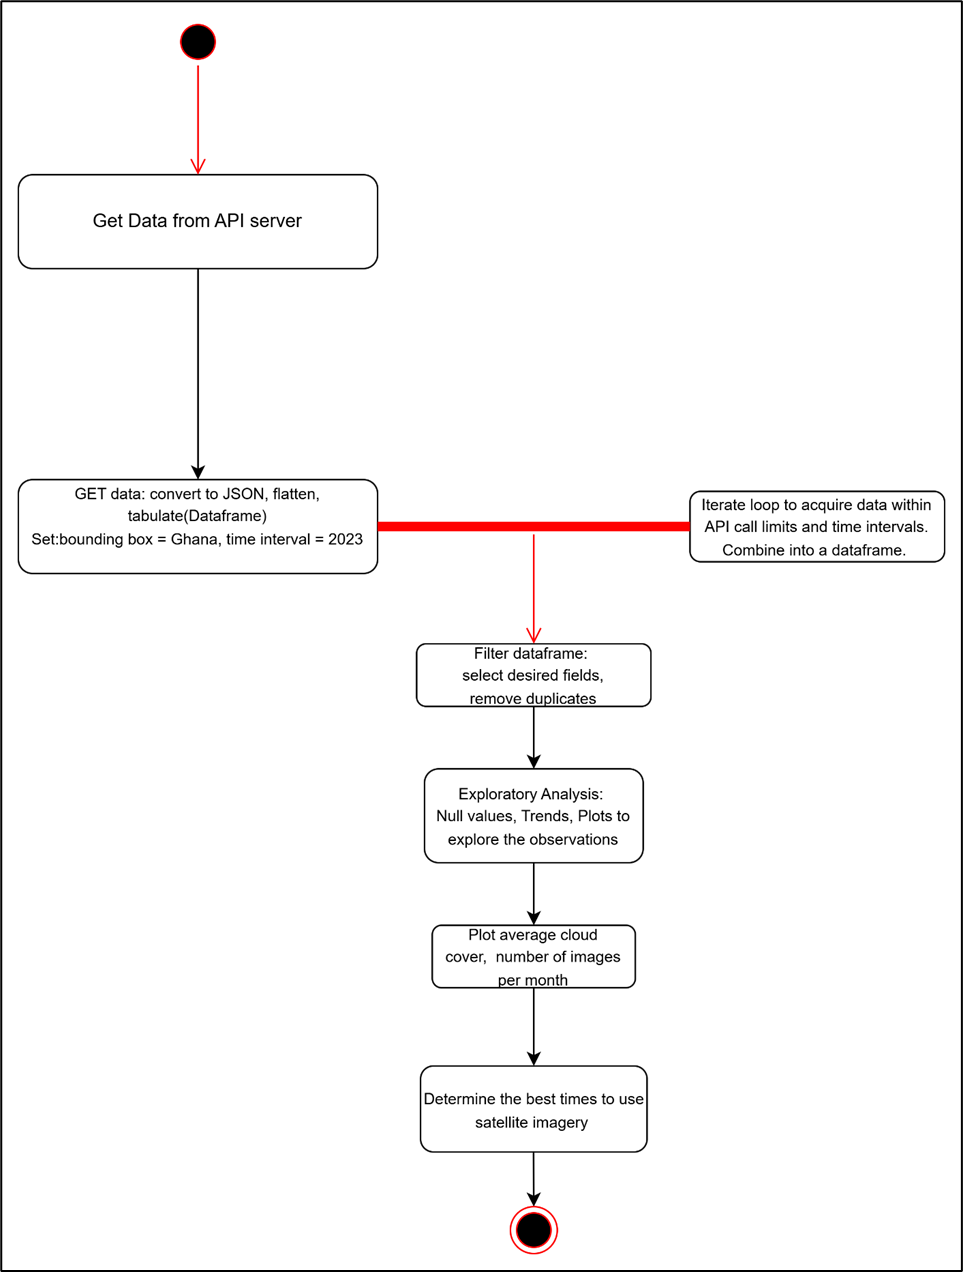

Figure 1: Satellite imagery analysis workflow

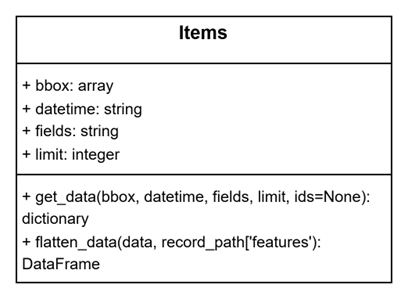

Figure 2: UML Class Diagram for Item() class showing methods and properties, where bbox = bounding box.

## Data Processing

The code used to run this analysis is the SP_Ghana_flattened.py file (See accompanying documentation). 
The relevant python packages are imported as shown in the cell below:

In [22]:
import SP_Ghana_flattened as sgf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import geopandas as gpd
import datetime as dt
from dateutil.relativedelta import relativedelta

Display all the columns of the results

In [23]:
#pd.set_option('display.max_columns',None)


Creating a class instance, flatten and load data to dataframe.

In [24]:
bbox = "-3.24437008301, 4.71046214438, 1.0601216976, 11.0983409693" #Ghana
""" bbox = bounding box """

fields = [
    'properties.eo:cloud_cover',
    'properties.datetime',
    'geometry.coordinates',
    'properties.platform',
    'id'
    ]

datetime = "2023-01-01T00:00:00Z/2023-12-31T23:59:59Z"

limit = 350

#Instantiate class
items = sgf.Items()

# First request to get the initial batch of data
json_items = items.get_data(bbox, fields, datetime, limit=limit)

# Flatten the response data
flatten_df1 = items.flatten_data(json_items)

#flatten_df1.head()

Sending request with params: {'bbox': '-3.24437008301, 4.71046214438, 1.0601216976, 11.0983409693', 'fields': 'properties.eo:cloud_cover,properties.datetime,geometry.coordinates,properties.platform,id', 'datetime': '2023-01-01T00:00:00Z/2023-12-31T23:59:59Z', 'limit': 350}


As shown above, the request call to the API has a positive response. Now extending the call to the entire time interval using a loop:

In [25]:

# Specifying bounding box and fields
bbox = "-3.24437008301, 4.71046214438, 1.0601216976, 11.0983409693" 
""" The coordinates are obtained from (https://gist.github.com/graydon/11198540#)."""

fields = [
    'properties.eo:cloud_cover',
    'properties.datetime',
    'geometry.coordinates',
    'properties.platform',
    'id'
]

start_date = dt.date(2022, 12, 31)
end_date = dt.date(2024, 1, 2)

# Setting last datetime to end of previous iteration and converting to a datetime object 
last_datetime = pd.to_datetime(flatten_df1['properties.datetime'].max())  

# Adding 1 second to the last datetime to avoid overlap
next_datetime = last_datetime + pd.Timedelta(seconds=1)

# Formatting new datetime
next_datetime_str = next_datetime.strftime("%Y-%m-%dT%H:%M:%SZ")

# Instantiate class 
items = sgf.Items()

# List of date ranges to hold the loop datetimes
date_ranges = []
temp_start_date = start_date

while temp_start_date <= end_date:
    # Define the start and end of each month
    temp_end_date = temp_start_date + relativedelta(months=1) - dt.timedelta(days=1) 
    
    # Checking the final range ends at the end_date
    if temp_end_date > end_date:
        temp_end_date = end_date  
    
    # Append the date ranges to the list 
    date_ranges.append([temp_start_date, temp_end_date])
    
    # Set the next start date as the first day of the next month
    temp_start_date = temp_end_date + dt.timedelta(days=1)

# Initialize empty list to store data frames
all_frames = []

# Iterate API requests over the datetime range 
for start_date, end_date in date_ranges:
    # Format the datetime range for the API call using the format YYYY-MM-DDTHH:MM:SSZ
    datetime_range = f"{start_date}T00:00:00Z/{end_date}T23:59:59Z"
    print(f"Fetching data for {datetime_range}")
    
    # Get data from the API for this date range
    json_items = items.get_data(bbox, fields, datetime_range, limit=350)
    
    if json_items:  # If there is data returned
        flattened_df = items.flatten_data(json_items)
        all_frames.append(flattened_df)

# Concatenate all the collected data into one DataFrame
final_df = pd.concat(all_frames, ignore_index=True)


# Print the total number of rows fetched
print("Total number of rows:", len(final_df))


Fetching data for 2022-12-31T00:00:00Z/2023-01-30T23:59:59Z
Sending request with params: {'bbox': '-3.24437008301, 4.71046214438, 1.0601216976, 11.0983409693', 'fields': 'properties.eo:cloud_cover,properties.datetime,geometry.coordinates,properties.platform,id', 'datetime': '2022-12-31T00:00:00Z/2023-01-30T23:59:59Z', 'limit': 350}
Fetching data for 2023-01-31T00:00:00Z/2023-02-27T23:59:59Z
Sending request with params: {'bbox': '-3.24437008301, 4.71046214438, 1.0601216976, 11.0983409693', 'fields': 'properties.eo:cloud_cover,properties.datetime,geometry.coordinates,properties.platform,id', 'datetime': '2023-01-31T00:00:00Z/2023-02-27T23:59:59Z', 'limit': 350}
Fetching data for 2023-02-28T00:00:00Z/2023-03-27T23:59:59Z
Sending request with params: {'bbox': '-3.24437008301, 4.71046214438, 1.0601216976, 11.0983409693', 'fields': 'properties.eo:cloud_cover,properties.datetime,geometry.coordinates,properties.platform,id', 'datetime': '2023-02-28T00:00:00Z/2023-03-27T23:59:59Z', 'limit': 350

checking the time interval is met

In [26]:
final_df['properties.datetime'].head()

0    2023-01-30T18:28:23.342147Z
1    2023-01-30T18:27:58.342322Z
2    2023-01-30T18:27:33.342497Z
3    2023-01-30T18:27:08.342673Z
4    2023-01-30T18:26:41.335169Z
Name: properties.datetime, dtype: object

In [27]:
final_df['properties.datetime'].tail()

4437    2023-12-28T10:15:52.655645Z
4438    2023-12-28T10:15:28.739189Z
4439    2023-12-28T10:15:04.831205Z
4440    2023-12-28T10:14:40.914749Z
4441    2023-12-28T10:14:17.006765Z
Name: properties.datetime, dtype: object

The conditions of the date time interval have been met as seen in the first and last rows shown in the code above. Next step is to filter the dataframe to obtain the fields of interest (See Table 1).

In [28]:
 #Fields of interest
desired_columns = [
     'bbox', 
     'id', 
     'collection', 
     'geometry.coordinates', 
     'properties.datetime', 
     'properties.eo:cloud_cover', 
     'properties.platform'
 ]
  
# Filtering the columns to keep the desired ones
filtered_df = final_df[desired_columns].copy()

#Checking dataframe has been appropriately defined
print('Table 1: Filtered dataframe showing first 5 rows and relevant fields')
filtered_df['id'] =  filtered_df['id'].str.wrap(80)
print(filtered_df.head())

#check len(filtered_df)

Table 1: Filtered dataframe showing first 5 rows and relevant fields
                                           bbox  \
0  [-5.141977, 10.584508, -2.569555, 12.539924]   
1   [-4.832552, 9.072087, -2.271056, 11.031441]   
2    [-4.522804, 7.559572, -1.970628, 9.522955]   
3    [-4.212748, 6.047002, -1.667892, 8.014493]   
4    [-3.902137, 4.291239, -1.314672, 6.506059]   

                                                  id      collection  \
0  S1A_IW_GRDH_1SDV_20230130T182810_20230130T1828...  sentinel-1-grd   
1  S1A_IW_GRDH_1SDV_20230130T182745_20230130T1828...  sentinel-1-grd   
2  S1A_IW_GRDH_1SDV_20230130T182720_20230130T1827...  sentinel-1-grd   
3  S1A_IW_GRDH_1SDV_20230130T182655_20230130T1827...  sentinel-1-grd   
4  S1A_IW_GRDH_1SDV_20230130T182626_20230130T1826...  sentinel-1-grd   

                                geometry.coordinates  \
0  [[[-2.8792576, 12.5378241], [-5.1422898, 12.09...   
1  [[[-2.5824262, 11.0293905], [-4.8329116, 10.58...   
2  [[[-2.2834676, 9.520

Since there are different satellites passing over the same area, need to identify duplicates in the dataset and drop them before visualising the data.

In [29]:
filtered_df.drop_duplicates(
    subset=['geometry.coordinates'], 
    keep='first', 
    inplace=False, 
    ignore_index=True
)
""" return filtered dataframe with no duplicates on repeated geometry coordinates. 

    Keep first instance and index from 0...n-1 as per python pandas documentation.
""" 

print(f"Length of filtered dataframe after dropping duplicates = {len(filtered_df)}")

Length of filtered dataframe after dropping duplicates = 4442


## Exploratory Data Analysis

### Null values analysis:

From the results of the filtered data frame (Table 1), there are some null (NaN) values in the cloud cover column. To understand the extent of null values in the dataframe, isnull() method is called to check for null values. The results should provide an insight into where potential issues lie. 

In [30]:
filtered_df.isnull().any()
#return bool response on presence of null values in columns

bbox                         False
id                           False
collection                   False
geometry.coordinates         False
properties.datetime          False
properties.eo:cloud_cover     True
properties.platform          False
dtype: bool

The results of the isnull() method indicate that the 'properties.eo:cloud_cover' column has  null (NaN) values. 
To determine where these are occuring and the number of instances, a new dataframe (see Table 2) is created as below:

In [31]:
nan_rows = filtered_df[filtered_df.isnull().T.any()] #solution from stack overflow
""" return any null values within the filtered dataframe."""

print(f"Length of dataframe = {len(nan_rows)} rows")

print('Table 2: Header of results from the isnull() method for null values in filtered_df')
print(nan_rows.head())

Length of dataframe = 124 rows
Table 2: Header of results from the isnull() method for null values in filtered_df
                                           bbox  \
0  [-5.141977, 10.584508, -2.569555, 12.539924]   
1   [-4.832552, 9.072087, -2.271056, 11.031441]   
2    [-4.522804, 7.559572, -1.970628, 9.522955]   
3    [-4.212748, 6.047002, -1.667892, 8.014493]   
4    [-3.902137, 4.291239, -1.314672, 6.506059]   

                                                  id      collection  \
0  S1A_IW_GRDH_1SDV_20230130T182810_20230130T1828...  sentinel-1-grd   
1  S1A_IW_GRDH_1SDV_20230130T182745_20230130T1828...  sentinel-1-grd   
2  S1A_IW_GRDH_1SDV_20230130T182720_20230130T1827...  sentinel-1-grd   
3  S1A_IW_GRDH_1SDV_20230130T182655_20230130T1827...  sentinel-1-grd   
4  S1A_IW_GRDH_1SDV_20230130T182626_20230130T1826...  sentinel-1-grd   

                                geometry.coordinates  \
0  [[[-2.8792576, 12.5378241], [-5.1422898, 12.09...   
1  [[[-2.5824262, 11.0293905], [-4

Plotting the 'properties.platform' columns to identify whether this is due to a specific satellite/sensor failure:

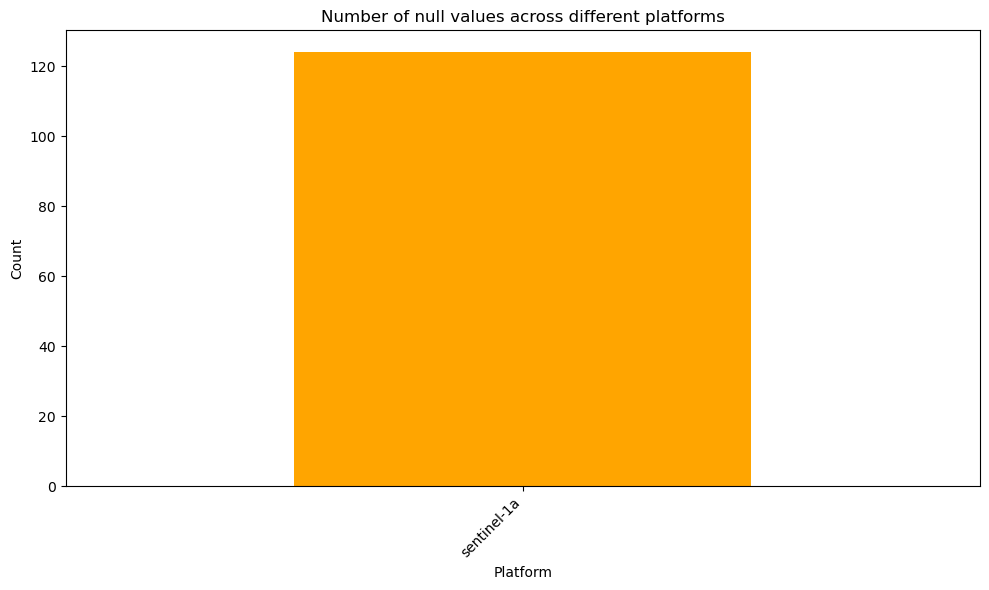

Figure 3: Number of null values across different platforms


In [32]:
# Group by 'properties.platforms' and count occurrences
platform_counts = nan_rows.groupby('properties.platform')\
                      ['properties.platform'].count()
""" return number of instances of platform. """

# Plotting platforms vs platform_counts
plt.figure(figsize=(10, 6))  
platform_counts.plot(kind='bar', color='orange')
plt.title('Number of null values across different platforms')
plt.xlabel('Platform')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

print('Figure 3: Number of null values across different platforms')


From the bar plot in Figure 3 above, it is clear that there was an issue with the Sentinel-1a sensor. All 124 null values are from Sentinel-1a.

### Temporal extent analysis:
#### Number of images captured by different platforms:

The number of images generated by the platforms(non-null values), is analysed similarly to the null values. 
The dataframe in question is the filtered dataframe. 


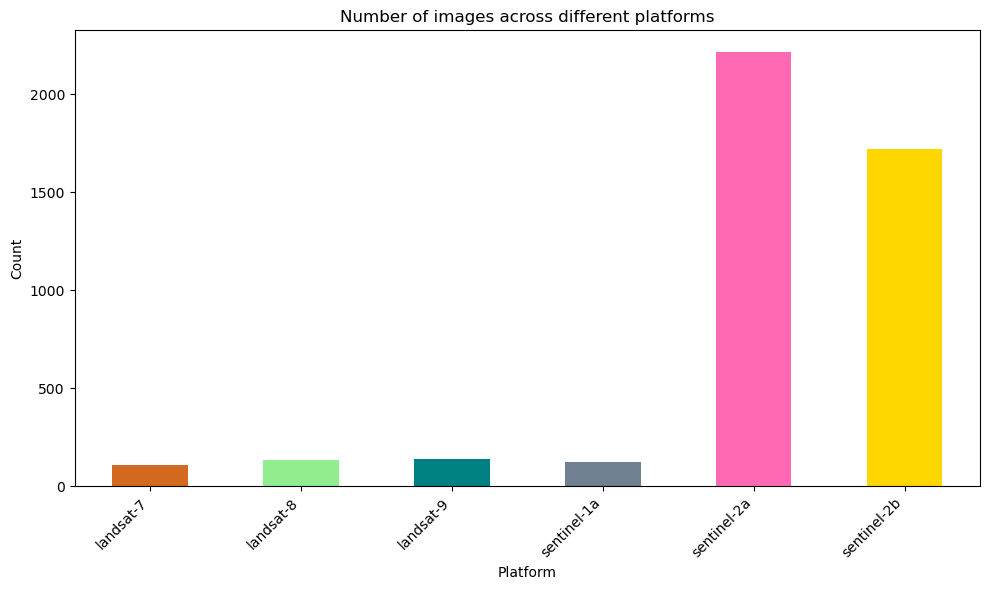

Figure 4: Number of images across different platforms


In [33]:
# Group by 'properties.platforms' and count occurrences
all_platforms = filtered_df.groupby('properties.platform')['properties.platform'].count()

# Create the bar graph
color = ['chocolate', 'lightgreen', 'teal', 'slategray', 'hotpink', 'gold']  
plt.figure(figsize=(10, 6))  
all_platforms.plot(kind='bar', color=color)
plt.title('Number of images across different platforms')
plt.xlabel('Platform')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Figure 4: Number of images across different platforms')


The results shown in Figure 4 above indicate that a vast majority of satellite images across Ghana are from Sentinel-2a and Sentinel-2b platforms. Table 3 below, shows the exact numbers for reference.

In [34]:
print('Table 3: Number of images captured by platform across 2023')
all_platforms

Table 3: Number of images captured by platform across 2023


properties.platform
landsat-7       108
landsat-8       135
landsat-9       138
sentinel-1a     124
sentinel-2a    2216
sentinel-2b    1721
Name: properties.platform, dtype: int64

#### Number of images captured and average cloud cover per month across the year 2023 in Ghana:
In order to visualise the trend of images across the year, the data is resampled to monthly groups and then plotted as in Figure 5 below.

In [35]:
# ensure date is in datetime to allow for resampling
filtered_df['properties.datetime']= pd.to_datetime(
    filtered_df['properties.datetime'], 
    format='ISO8601'
) 
""" convert date values from string to datetime. """

#filtered_df.head()

' convert date values from string to datetime. '

In [36]:
filtered_df = filtered_df.set_index('properties.datetime')
""" return filtered_df with the column'properties.datetime' as the index."""

monthly_data = filtered_df.resample('M', origin = '2023/01/01', offset = '0h0min').agg(
    images_sum = ('properties.eo:cloud_cover', 'count'),
    avg_cloud_cover = ('properties.eo:cloud_cover', 'mean')
)
""" return new dataframe for visualisation of monthly image count and average cloud cover."""

#monthly_data.head()

' return new dataframe for visualisation of monthly image count and average cloud cover.'

Calculating the monthly data:

In [37]:
# Reset index to have datetime as a column 
monthly_data = monthly_data.reset_index()

print(f"Length of monthly_data dataframe = {len(monthly_data)} rows")

#monthly_data.head()

Length of monthly_data dataframe = 13 rows


Plotting monthly data:

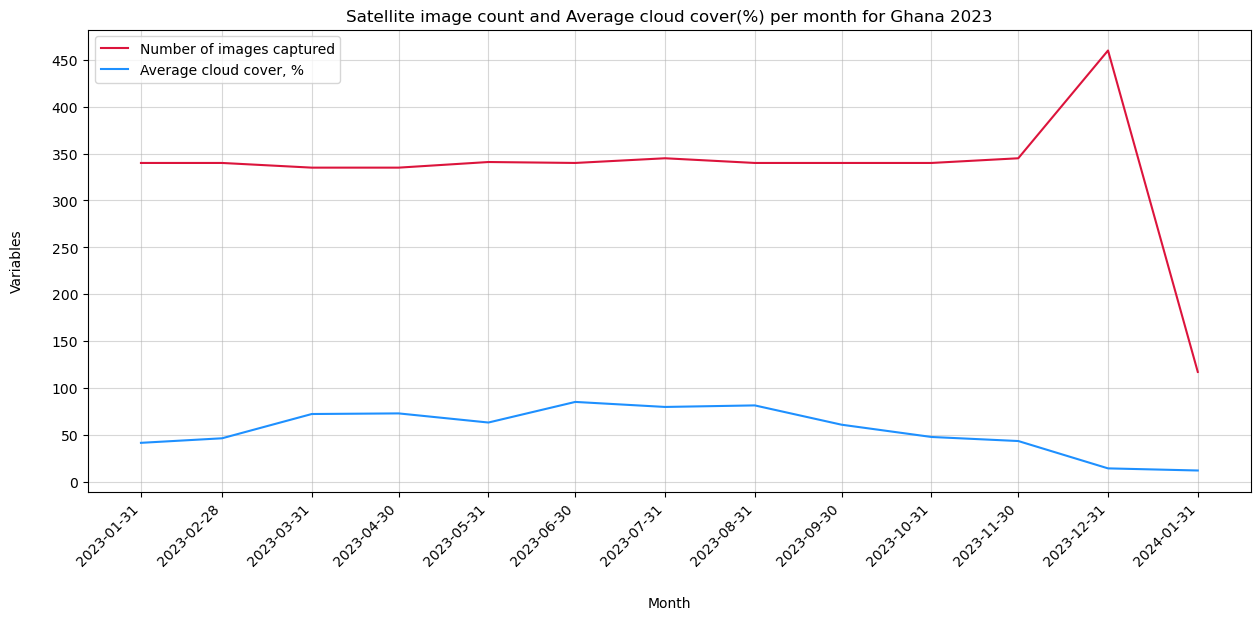

Figure 5: Monthly number of images and average cloud cover over Ghana 2023


In [42]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(
    monthly_data['properties.datetime'], 
    monthly_data['images_sum'], 
    color='crimson', 
    label='Number of images captured'
)
ax.plot(
    monthly_data['properties.datetime'], 
    monthly_data['avg_cloud_cover'], 
    color='dodgerblue', 
    label='Average cloud cover, %'
)
ax.grid(alpha=0.5)
ax.set_xlabel('Month')
ax.set_ylabel('Variables')
ax.set_xticks(monthly_data['properties.datetime']) 
ax.xaxis.labelpad = 20
ax.set_yticks(np.arange(0, 500, 500/10))
ax.yaxis.labelpad = 20
plt.xticks(rotation=45, ha='right')
plt.title('Satellite image count and Average cloud cover(%) per month for Ghana 2023')
plt.legend()
plt.show()

      
print('Figure 5: Monthly number of images and average cloud cover over Ghana 2023')

The temporal extent plot generated in Figure(5) reveals no data for the start of January 2023. The trend indicates that for average cloud cover > 50%,  there is less sensitivity in the sensors responses for images captured. However, once the average cloud cover drops below 50%, a significant response is observed. The highest number of images captured was obtained within December 2023, which also coincided with the lowest cloud cover of 2023. From Table 4 below, these are 460 images when average cloud cover was 14%.

The plot in Figure 5 also reveals that Ghana is largely very cloudy for most of the year. From August, a downward trajectory is seen of cloud cover going all the way to January of the next year. From the values in table 4 this is a drop from 81% to 14% which is significant. 

In [39]:
print('Table 4: Number of images and average cloud cover(%) per month across Ghana 2023')
monthly_data

Table 4: Number of images and average cloud cover(%) per month across Ghana 2023


,properties.datetime,images_sum,avg_cloud_cover
0,2023-01-31 00:00:00+00:00,340,41.338821
1,2023-02-28 00:00:00+00:00,340,46.185472
2,2023-03-31 00:00:00+00:00,335,72.093764
3,2023-04-30 00:00:00+00:00,335,72.741515
4,2023-05-31 00:00:00+00:00,341,63.003574
5,2023-06-30 00:00:00+00:00,340,84.994675
6,2023-07-31 00:00:00+00:00,345,79.635378
7,2023-08-31 00:00:00+00:00,340,81.278373
8,2023-09-30 00:00:00+00:00,340,60.663713
9,2023-10-31 00:00:00+00:00,340,47.596868


In [43]:
monthly_data 

print('Table 5: Correlation between number or images and cloud cover') 
monthly_data.corr()
 

Table 5: Correlation between number or images and cloud cover


,properties.datetime,images_sum,avg_cloud_cover
properties.datetime,1.000000,-0.202817,-0.481942
images_sum,-0.202817,1.000000,0.222212
avg_cloud_cover,-0.481942,0.222212,1.000000


## Summary

In conclusion, the analysis suggests an inverse relationship between average cloud cover and time over Ghana. This relationship is not strong as shown in the correlations in Table 5 below. It corroborates the trend observed in the temporal extent in Figure 5. There is not clear correlation between number of images and average cloud cover as the coefficient is very low. To better understand this, more analysis should investigate the null values and the timeframe in which they occurred. This would shed light if it was a random event or a systematic issue. The most favourable satellite platforms for imagery over Ghana are the Sentinel-2a and Sentinel-2b platforms. Sentinel-1a returned only null values across the entire year(see Figure 3 and Table 3) thus not appropriate for analysis of cloud cover over Ghana. The best time to use satellite imagery over Ghana is in December as the rest of the year has significant cloud coverage >50%.

---
## Extended Analysis: Sentinel-2 Platforms Only
Following the platform identification above, the analysis is refined to focus on **Sentinel-2a and Sentinel-2b** — the dominant platforms with valid cloud cover data over Ghana. Sentinel-1a is excluded as it returned only null cloud cover values across the entire year (see Figure 3).

In [ ]:
# Filter to Sentinel-2 platforms only (exclude Sentinel-1a and Landsat)
sentinel_df = filtered_df[
    filtered_df['properties.platform'].isin(['sentinel-2a', 'sentinel-2b'])
].copy()

print(f'Total records (all platforms):      {len(filtered_df)}')
print(f'Sentinel-2 only records:            {len(sentinel_df)}')
print(f'Platforms in filtered data:         {sentinel_df["properties.platform"].unique()}')
print(f'Null cloud cover values remaining:  {sentinel_df["properties.eo:cloud_cover"].isnull().sum()}')

In [ ]:
# Resample Sentinel-2 data to monthly groups
sentinel_monthly = sentinel_df.resample(
    'M', origin='2023/01/01', offset='0h0min'
).agg(
    images_sum=('properties.eo:cloud_cover', 'count'),
    avg_cloud_cover=('properties.eo:cloud_cover', 'mean')
).reset_index()

print('Table 6: Sentinel-2 monthly image count and average cloud cover')
print(sentinel_monthly.to_string(index=False))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    sentinel_monthly['properties.datetime'],
    sentinel_monthly['images_sum'],
    color='crimson',
    marker='o',
    linewidth=2,
    label='Number of Sentinel-2 images captured'
)
ax.plot(
    sentinel_monthly['properties.datetime'],
    sentinel_monthly['avg_cloud_cover'],
    color='dodgerblue',
    marker='s',
    linewidth=2,
    label='Average cloud cover (%)'
)

# Shade months where cloud cover > 50% (poor imaging conditions)
for _, row in sentinel_monthly.iterrows():
    if row['avg_cloud_cover'] > 50:
        ax.axvspan(
            row['properties.datetime'] - pd.DateOffset(days=15),
            row['properties.datetime'] + pd.DateOffset(days=15),
            alpha=0.1, color='gray', label='_nolegend_'
        )

ax.axhline(y=50, color='orange', linestyle='--', linewidth=1.5,
           label='50% cloud cover threshold')

ax.grid(alpha=0.5)
ax.set_xlabel('Month')
ax.set_ylabel('Count / Cloud Cover (%)')
ax.set_xticks(sentinel_monthly['properties.datetime'])
ax.xaxis.labelpad = 20
ax.yaxis.labelpad = 20
plt.xticks(rotation=45, ha='right')
plt.title('Sentinel-2: Monthly Image Count and Average Cloud Cover (%) — Ghana 2023')
plt.legend()
plt.tight_layout()
plt.show()

print('Figure 6: Sentinel-2 monthly image count and average cloud cover over Ghana 2023')

In [ ]:
# Identify best months for Sentinel-2 imaging (cloud cover < 50%)
good_months = sentinel_monthly[sentinel_monthly['avg_cloud_cover'] < 50].copy()
good_months['month_name'] = good_months['properties.datetime'].dt.strftime('%B %Y')

print('Table 7: Best months for Sentinel-2 imaging over Ghana (avg cloud cover < 50%)')
print(good_months[['month_name', 'images_sum', 'avg_cloud_cover']]
      .rename(columns={
          'month_name': 'Month',
          'images_sum': 'Images Captured',
          'avg_cloud_cover': 'Avg Cloud Cover (%)'
      }).to_string(index=False))

best = sentinel_monthly.loc[sentinel_monthly['avg_cloud_cover'].idxmin()]
print(f"\nOptimal month: {best['properties.datetime'].strftime('%B %Y')} "
      f"— {best['avg_cloud_cover']:.1f}% avg cloud cover, "
      f"{int(best['images_sum'])} images")

### Sentinel-2 Summary

Refining the analysis to Sentinel-2 platforms confirms the earlier findings while providing a clearer picture of imaging quality:

- **Best months** for Sentinel-2 imaging are **November through January**, where average cloud cover drops below 50%
- **December** remains the optimal month with the lowest cloud cover and highest image count
- The **June–August** period should be avoided — average cloud cover exceeds 80%, severely limiting the usefulness of any imagery captured
- Sentinel-2a and Sentinel-2b together account for **87.9%** of all valid cloud cover records over Ghana in 2023, making them the most appropriate platforms for this analysis